In [ ]:
LDA
Linear Discriminant analysis is a dimensionality reductiontechnique and classification methodthat finds a linear combination of features that best seperates two  or more classes.

LDA reduces dimensions like PCA, but with a focus on a class discrimination , not just variance.

In [1]:
# imporyt libary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [5]:
X, y = make_classification(
    n_samples= 300,
    n_features = 6,
    n_informative=4,
    n_redundant = 1,
    n_classes =3,
    n_clusters_per_class=1,
    random_state= 42
)

feature_names = [f"Feature_{i}" for i in range(1,7)]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name= "Target")

In [6]:
# apply LDA
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X,y)

X_lda_df= pd.DataFrame(X_lda, columns=["LD1","LD2"])
X_lda_df["Target"] = y





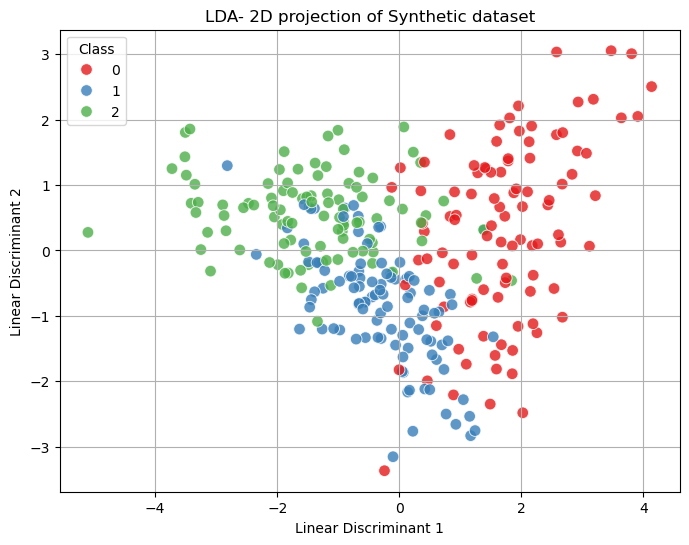

In [8]:
# visualization
plt.figure(figsize=(8,6))
sns.scatterplot(
    data = X_lda_df,
    x= 'LD1', y='LD2',
    hue='Target',
    palette='Set1',
    s=70,
    alpha=0.8
)
plt.title("LDA- 2D projection of Synthetic dataset")
plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.legend(title='Class')
plt.grid(True)
plt.show()

In [ ]:
# Association Rule Mining
data mining technique used to find  interesting relationship or pattern among a large set of items in dataset

Support - the how common the rule is
confidence- how reliable the rule is
Lift - How much the presence of A increses the likelihoodof B(>1 means positive association)

Ariori Algorithm-
works by finding frequent itemsets(sets of items appearing often together).
uses a bottom-up-approach and minimum support threshold
iteratively builds larger itemsets from smaller one

1.set minimum support a nd confidence


In [ ]:
use case- Market Basket Analysis
 goal- identify frequently purchased product combinations in a supermarket


In [10]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 17.9 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [11]:
# 1 import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules

In [12]:
# create a dataset
dataset = [
    ['milk','bread','eggs'],
    ['milk','bread'],
    ['milk','butter'],
    ['bread','butter'],
    ['milk','bread','butter','eggs'],
    ['bread','butter','jam'],
    ['milk','bread','jam'],
    ['milk','bread','butter'],
    ['bread','eggs'],
    ['milk','butter','jam']
]
transactions_df = pd.DataFrame(dataset, columns=['Item_1','Item_2','Item_3','Item_4']).fillna('')

print("Synthetic Transactions dataset:")
print(transactions_df)

Synthetic Transactions dataset:
  Item_1  Item_2  Item_3 Item_4
0   milk   bread    eggs       
1   milk   bread               
2   milk  butter               
3  bread  butter               
4   milk   bread  butter   eggs
5  bread  butter     jam       
6   milk   bread     jam       
7   milk   bread  butter       
8  bread    eggs               
9   milk  butter     jam       


In [15]:
all_items = sorted(set(item for transaction in dataset for item in transaction)) # create a list all unique item
encoded_df = pd.DataFrame(0, index=np.arange(len(dataset)), columns=all_items) #initialize an empty dataframe for one hot encoding
for i, transaction in enumerate(dataset):  # fill 1 where item exist in transactionj
    for item in transaction:
        encoded_df.loc[i, item]= 1
print("One-Hot Encoded Transaction Data:")
print(encoded_df)
                       

One-Hot Encoded Transaction Data:
   bread  butter  eggs  jam  milk
0      1       0     1    0     1
1      1       0     0    0     1
2      0       1     0    0     1
3      1       1     0    0     0
4      1       1     1    0     1
5      1       1     0    1     0
6      1       0     0    1     1
7      1       1     0    0     1
8      1       0     1    0     0
9      0       1     0    1     1


In [16]:
# apply apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(encoded_df, min_support= 0.3, use_colnames= True)
print("Frequent itemsets:")
print(frequent_itemsets)

Frequent itemsets:
   support         itemsets
0      0.8          (bread)
1      0.6         (butter)
2      0.3           (eggs)
3      0.3            (jam)
4      0.7           (milk)
5      0.4  (bread, butter)
6      0.3    (bread, eggs)
7      0.5    (bread, milk)
8      0.4   (milk, butter)


C:\Users\anokh\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


In [19]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
print("Association Rules:")
print(rules[['antecedents','consequents','support','confidence','lift']])

Association Rules:
  antecedents consequents  support  confidence  lift
0     (bread)      (eggs)      0.3       0.375  1.25
1      (eggs)     (bread)      0.3       1.000  1.25
